In [ ]:
# Step 1: Upload dataset from your computer to Google Colab

from google.colab import files

uploaded = files.upload()

Saving open-university-learning-analytics-dataset.zip to open-university-learning-analytics-dataset.zip


In [ ]:
# Step 2: Extract the ZIP file

import zipfile

zip_file = "open-university-learning-analytics-dataset.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("oulad_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
# Step 3: Import important libraries for data analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 4: Load important dataset files

studentInfo = pd.read_csv("oulad_dataset/studentInfo.csv")
studentAssessment = pd.read_csv("oulad_dataset/studentAssessment.csv")
assessments = pd.read_csv("oulad_dataset/assessments.csv")
studentVle = pd.read_csv("oulad_dataset/studentVle.csv")
vle = pd.read_csv("oulad_dataset/vle.csv")

# Display first few rows
studentInfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [ ]:
# Step 5: Check dataset structure and missing values

studentInfo.info()
studentInfo.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,1111
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [ ]:
# Step 5: Check dataset structure and missing values

studentInfo.info()
studentInfo.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,1111
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [ ]:
# Step 6: Convert final_result into dropout label

studentInfo['dropout'] = studentInfo['final_result'].apply(
    lambda x: 1 if x == 'Withdrawn' else 0
)

studentInfo[['final_result','dropout']].head()

,final_result,dropout
0,Pass,0
1,Pass,0
2,Withdrawn,1
3,Pass,0
4,Pass,0


In [ ]:
# Step 7: Merge studentInfo and studentAssessment datasets

merged_data = pd.merge(studentInfo, studentAssessment, on='id_student', how='left')

merged_data.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,dropout,id_assessment,date_submitted,is_banked,score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,1752.0,18.0,0.0,78.0
1,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,1753.0,53.0,0.0,85.0
2,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,1754.0,115.0,0.0,80.0
3,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,1755.0,164.0,0.0,85.0
4,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,1756.0,212.0,0.0,82.0


In [ ]:
# Step 8: Replace missing values with 0

merged_data.fillna(0, inplace=True)

In [ ]:
# Step 9: Convert categorical columns into numerical values safely

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ['gender','region','highest_education','imd_band','age_band']

for col in categorical_columns:

    # Convert all values to string to avoid int/string mix error
    merged_data[col] = merged_data[col].astype(str)

    # Apply label encoding
    merged_data[col] = le.fit_transform(merged_data[col])

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [ ]:
# Step 10: Select input features and target variable

X = merged_data.drop(['dropout','final_result'], axis=1)
y = merged_data['dropout']

print("Feature shape:", X.shape)

Feature shape: (213166, 15)


In [ ]:
# Step 11: Split dataset into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (170532, 15)
Testing samples: (42634, 15)


In [ ]:
# Step 12: Import Random Forest model and evaluation metrics: It non-linear relationships and mixed features well.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Fix: Convert all remaining string columns to numeric values

from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Find columns that still contain text
for col in X_train.select_dtypes(include=['object']).columns:

    # Convert training data
    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # Convert testing data
    X_test[col] = le.transform(X_test[col].astype(str))

print("All text columns converted successfully!")

All text columns converted successfully!


In [ ]:
# Step 13: Train the model using training data

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
print(X_train.dtypes)

code_module               int64
code_presentation         int64
id_student                int64
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
id_assessment           float64
date_submitted          float64
is_banked               float64
score                   float64
dtype: object


In [ ]:
# Step 14: Make predictions on test data

y_pred = rf_model.predict(X_test)

In [ ]:
# Step 15: Calculate accuracy and evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9280621100530093

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     36549
           1       0.91      0.55      0.69      6085

    accuracy                           0.93     42634
   macro avg       0.92      0.77      0.82     42634
weighted avg       0.93      0.93      0.92     42634



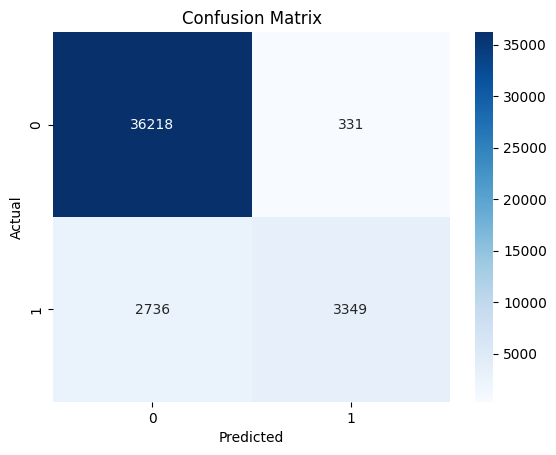

In [ ]:
# Step 16: Visualize confusion matrix

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Step 17: Check which features influence dropout prediction

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

top_features = feature_importances.sort_values(ascending=False).head(10)

print("Top Important Features:")
print(top_features)

Top Important Features:
id_student           0.156725
date_submitted       0.150729
id_assessment        0.141324
score                0.124984
region               0.084390
imd_band             0.081069
studied_credits      0.051655
code_module          0.047439
code_presentation    0.042757
highest_education    0.031485
dtype: float64


In [ ]:
# Step 18A: Check available files in the current directory

import os

print(os.listdir())

['.config', 'open-university-learning-analytics-dataset.zip', 'oulad_dataset', 'sample_data']


In [ ]:
# Step 18B: Extract the OULAD dataset ZIP file

import zipfile

zip_path = '/content/open-university-learning-analytics-dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
# Step 18C: Check files after extraction

print(os.listdir('/content'))

['.config', 'vle.csv', 'courses.csv', 'assessments.csv', 'open-university-learning-analytics-dataset.zip', 'oulad_dataset', 'studentInfo.csv', 'anonymiseddata', 'studentVle.csv', 'studentAssessment.csv', 'studentRegistration.csv', 'sample_data']


In [ ]:
# Step 18D: Load the studentVle dataset

import pandas as pd

student_vle = pd.read_csv('/content/studentVle.csv')

print(student_vle.head())

  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1


In [ ]:
# Step 18E: Calculate total clicks per student

vle_activity = student_vle.groupby('id_student')['sum_click'].sum().reset_index()

vle_activity.rename(columns={'sum_click':'total_clicks'}, inplace=True)

print(vle_activity.head())

   id_student  total_clicks
0        6516          2791
1        8462           656
2       11391           934
3       23629           161
4       23698           910


In [ ]:
# Step 19: Merge engagement feature with main dataset

merged_data = merged_data.merge(vle_activity, on='id_student', how='left')

# Replace missing values with 0 (students who never clicked anything)
merged_data['total_clicks'] = merged_data['total_clicks'].fillna(0)

print(merged_data.head())

  code_module code_presentation  id_student  gender  region  \
0         AAA             2013J       11391       1       0   
1         AAA             2013J       11391       1       0   
2         AAA             2013J       11391       1       0   
3         AAA             2013J       11391       1       0   
4         AAA             2013J       11391       1       0   

   highest_education  imd_band  age_band  num_of_prev_attempts  \
0                  1        10         2                     0   
1                  1        10         2                     0   
2                  1        10         2                     0   
3                  1        10         2                     0   
4                  1        10         2                     0   

   studied_credits disability final_result  dropout  id_assessment  \
0              240          N         Pass        0         1752.0   
1              240          N         Pass        0         1753.0   
2             

In [ ]:
# Step 20: Check dataset shape and columns

print("Dataset shape:", merged_data.shape)
print(merged_data.columns)

Dataset shape: (213166, 18)
Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'dropout',
       'id_assessment', 'date_submitted', 'is_banked', 'score',
       'total_clicks'],
      dtype='object')


In [ ]:
# Step 21: Define features and target again

X = merged_data.drop(columns=['final_result'])
y = merged_data['final_result']

print(X.shape)

(213166, 17)


In [ ]:
# Step 22: Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (170532, 17)
Test size: (42634, 17)


In [ ]:
# Step 23 FIX: Convert all remaining categorical columns to numbers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

print("All categorical columns converted to numeric.")

All categorical columns converted to numeric.


In [ ]:
# Step 24: Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)

rf_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
# Step 25: Predict test data

y_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9074213069381245


In [ ]:
# Detailed evaluation metrics

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 4460    19  1593     0]
 [   17  4843  1878     0]
 [  138   302 23299     0]
 [    0     0     0  6085]]

Classification Report:
              precision    recall  f1-score   support

 Distinction       0.97      0.73      0.83      6072
        Fail       0.94      0.72      0.81      6738
        Pass       0.87      0.98      0.92     23739
   Withdrawn       1.00      1.00      1.00      6085

    accuracy                           0.91     42634
   macro avg       0.94      0.86      0.89     42634
weighted avg       0.91      0.91      0.90     42634



In [ ]:
# Step 28: Identify students predicted as at-risk (fail/withdraw)

# Add predictions to the test dataset
results = X_test.copy()
results['Actual_Result'] = y_test
results['Predicted_Result'] = y_pred

# Show first few rows
print(results.head())

        code_module  code_presentation  id_student  gender  region  \
164283            5                  1      606990       1       6   
31062             1                  2       72400       0       0   
22684             1                  1      572163       0       2   
161798            5                  1      596490       1       6   
98125             3                  1      473340       1      11   

        highest_education  imd_band  age_band  num_of_prev_attempts  \
164283                  2         4         0                     0   
31062                   0         7         0                     0   
22684                   2         1         0                     0   
161798                  2         6         1                     0   
98125                   2         7         0                     0   

        studied_credits  disability  dropout  id_assessment  date_submitted  \
164283               60           0        0        34879.0            24

In [ ]:
# Step 29: Filter at-risk students

at_risk_students = results[results['Predicted_Result'] != 'Pass']

print("Number of at-risk students:", len(at_risk_students))
print(at_risk_students.head())

Number of at-risk students: 15864
       code_module  code_presentation  id_student  gender  region  \
31062            1                  2       72400       0       0   
22684            1                  1      572163       0       2   
98125            3                  1      473340       1      11   
78981            2                  3      654755       1       6   
31635            1                  2      250123       0      11   

       highest_education  imd_band  age_band  num_of_prev_attempts  \
31062                  0         7         0                     0   
22684                  2         1         0                     0   
98125                  2         7         0                     0   
78981                  0         3         0                     0   
31635                  2         1         0                     0   

       studied_credits  disability  dropout  id_assessment  date_submitted  \
31062              120           1        0        1

In [ ]:
# Step 30: Assign risk levels based on engagement

def assign_risk(clicks):
    if clicks < 50:
        return "High Risk"
    elif clicks < 200:
        return "Medium Risk"
    else:
        return "Low Risk"

at_risk_students['Risk_Level'] = at_risk_students['total_clicks'].apply(assign_risk)

print(at_risk_students[['total_clicks','Risk_Level']].head())

       total_clicks   Risk_Level
31062         420.0     Low Risk
22684         343.0     Low Risk
98125         341.0     Low Risk
78981         188.0  Medium Risk
31635         170.0  Medium Risk


/tmp/ipykernel_6271/1191810058.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  at_risk_students['Risk_Level'] = at_risk_students['total_clicks'].apply(assign_risk)


In [ ]:
# Step 31: Recommend interventions

def recommend_intervention(risk):

    if risk == "High Risk":
        return "Immediate mentor support and academic counseling"

    elif risk == "Medium Risk":
        return "Weekly progress monitoring and additional learning resources"

    else:
        return "Encourage continued engagement with course materials"

at_risk_students['Intervention'] = at_risk_students['Risk_Level'].apply(recommend_intervention)

print(at_risk_students[['Risk_Level','Intervention']].head())

        Risk_Level                                       Intervention
31062     Low Risk  Encourage continued engagement with course mat...
22684     Low Risk  Encourage continued engagement with course mat...
98125     Low Risk  Encourage continued engagement with course mat...
78981  Medium Risk  Weekly progress monitoring and additional lear...
31635  Medium Risk  Weekly progress monitoring and additional lear...


/tmp/ipykernel_6271/1713060593.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  at_risk_students['Intervention'] = at_risk_students['Risk_Level'].apply(recommend_intervention)


In [ ]:
# Step 32: Save intervention recommendations

at_risk_students.to_csv("dropout_intervention_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
# Step 33: Install required libraries for deep learning and graph learning

!pip install torch
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00


In [ ]:
# Step 34: Prepare sequential data from student activity

# Sort activity by student and date
student_vle = student_vle.sort_values(by=['id_student','date'])

# Group student activity as sequences
sequences = student_vle.groupby('id_student')['sum_click'].apply(list)

print(sequences.head())

id_student
6516     [1, 16, 1, 5, 2, 3, 13, 16, 17, 2, 1, 13, 20, ...
8462     [5, 1, 2, 1, 1, 1, 1, 13, 4, 2, 16, 3, 1, 4, 4...
11391    [16, 44, 1, 2, 1, 2, 2, 7, 10, 2, 11, 5, 1, 7,...
23629    [2, 10, 2, 3, 2, 4, 5, 1, 3, 2, 1, 1, 1, 1, 1,...
23698    [4, 1, 1, 1, 1, 1, 2, 1, 1, 58, 1, 1, 1, 5, 1,...
Name: sum_click, dtype: object


In [ ]:
# Step 35: Build LSTM model

import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=32, output_size=2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()

print(model)

LSTMModel(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


In [ ]:
# Step 36 Fix: Convert all categorical columns to numeric

# Find columns that contain text (object type)
categorical_cols = X.select_dtypes(include=['object']).columns

# Convert them using Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling completed successfully!")

Scaling completed successfully!


In [ ]:
print(X.dtypes)

code_module               int64
code_presentation         int64
id_student                int64
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
dropout                   int64
id_assessment           float64
date_submitted          float64
is_banked               float64
score                   float64
total_clicks            float64
dtype: object


In [ ]:
# Step 36: Convert all categorical (text) columns into numbers

# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Find all columns that contain text
categorical_cols = X.select_dtypes(include=['object']).columns

# Convert each text column into numbers
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

print("All categorical columns converted to numeric!")

All categorical columns converted to numeric!


In [ ]:
# Step 37: Scale the features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Transform the feature matrix
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")

Feature scaling completed!


In [ ]:
# Step 38: Split the scaled data for training and testing

from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train Test split completed!")

Train Test split completed!


In [ ]:
# Step 39: Reshape the data for LSTM model

import numpy as np

X_train_lstm = np.reshape(X_train_nn, (X_train_nn.shape[0], 1, X_train_nn.shape[1]))
X_test_lstm = np.reshape(X_test_nn, (X_test_nn.shape[0], 1, X_test_nn.shape[1]))

print("Data reshaped for LSTM!")

Data reshaped for LSTM!


In [ ]:
# Step 40: Build the LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential()

# LSTM layer
lstm_model.add(LSTM(64, input_shape=(1, X_train_nn.shape[1])))

# Output layer
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("LSTM Model Built!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Model Built!


In [ ]:
# Step 40A: Ensure all data is numeric for LSTM

# Convert X to numeric type
X = X.apply(pd.to_numeric, errors='coerce')

# Fill any missing values created during conversion
X = X.fillna(0)

# Convert target variable to numeric
y = pd.to_numeric(y, errors='coerce')
y = y.fillna(0)

print("All data converted to numeric format!")

All data converted to numeric format!


In [ ]:
# Step 40B: Scale the features again

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling completed!")

Scaling completed!


In [ ]:
# Step 40C: Split data for neural network

from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train Test split completed!")

Train Test split completed!


In [ ]:
# Step 40D: Reshape data into 3D for LSTM

import numpy as np

X_train_lstm = np.reshape(X_train_nn, (X_train_nn.shape[0], 1, X_train_nn.shape[1]))
X_test_lstm = np.reshape(X_test_nn, (X_test_nn.shape[0], 1, X_test_nn.shape[1]))

print("Data reshaped for LSTM!")

Data reshaped for LSTM!


In [ ]:
# Step 40E: Build LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

lstm_model = Sequential()

# Input layer
lstm_model.add(Input(shape=(1, X_train_nn.shape[1])))

# LSTM layer
lstm_model.add(LSTM(64))

# Output layer
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("LSTM Model Built Successfully!")

LSTM Model Built Successfully!


In [ ]:
# Step 41: Train the LSTM model

history = lstm_model.fit(
    X_train_lstm,
    y_train_nn,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_nn)
)

print("LSTM Training Completed!")

Epoch 1/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9990 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 4.7338e-05
Epoch 2/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 1.0000 - loss: 1.4580e-05 - val_accuracy: 1.0000 - val_loss: 2.3307e-06
Epoch 3/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 1.0000 - loss: 7.7558e-07 - val_accuracy: 1.0000 - val_loss: 1.4384e-07
Epoch 4/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 1.0000 - loss: 5.2143e-08 - val_accuracy: 1.0000 - val_loss: 1.2857e-08
Epoch 5/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 1.0000 - loss: 5.9849e-09 - val_accuracy: 1.0000 - val_loss: 2.7030e-09
LSTM Training Completed!


In [ ]:
# Step 48: Import libraries for GNN

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Step 49: Convert dataset into graph format

import numpy as np

# Convert features to tensor
x = torch.tensor(X_scaled, dtype=torch.float)

# Convert labels to tensor
y_tensor = torch.tensor(y.values, dtype=torch.long)

# Create simple edges (connect each student to next student)
edge_index = []

for i in range(len(X_scaled)-1):
    edge_index.append([i, i+1])
    edge_index.append([i+1, i])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

print("Graph structure created!")

Graph structure created!


In [ ]:
# Step 50: Create graph data object

graph_data = Data(x=x, edge_index=edge_index, y=y_tensor)

print(graph_data)

Data(x=[213166, 17], edge_index=[2, 426330], y=[213166])


In [ ]:
# Step 51: Define Graph Neural Network model

class GNN(torch.nn.Module):
    def __init__(self):
        super(GNN, self).__init__()

        self.conv1 = GCNConv(x.shape[1], 32)
        self.conv2 = GCNConv(32, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

print("GNN model created!")

GNN model created!


In [ ]:
# Step 52: Initialize model and optimizer

gnn_model = GNN()

optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)

print("GNN initialized!")

GNN initialized!


In [ ]:
# Step 53: Train the GNN model

for epoch in range(50):

    gnn_model.train()
    optimizer.zero_grad()

    out = gnn_model(graph_data)

    loss = F.nll_loss(out, graph_data.y)

    loss.backward()
    optimizer.step()

print("GNN Training Completed!")

GNN Training Completed!


In [ ]:
# Step 54: Evaluate GNN performance

gnn_model.eval()

pred = gnn_model(graph_data).argmax(dim=1)

correct = (pred == graph_data.y).sum()

accuracy = int(correct) / len(graph_data.y)

print("GNN Accuracy:", accuracy)

GNN Accuracy: 1.0


In [ ]:
# Step 55A: Evaluate Random Forest model

from sklearn.metrics import accuracy_score

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9074213069381245


In [ ]:
# Step 55B: Evaluate LSTM model

lstm_predictions = lstm_model.predict(X_test_lstm)

# Convert probabilities to 0 or 1
lstm_predictions = (lstm_predictions > 0.5).astype(int)

from sklearn.metrics import accuracy_score

lstm_accuracy = accuracy_score(y_test_nn, lstm_predictions)

print("LSTM Accuracy:", lstm_accuracy)

1333/1333 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
LSTM Accuracy: 1.0


In [ ]:
# Step 55C: Evaluate GNN model

gnn_model.eval()

pred = gnn_model(graph_data).argmax(dim=1)

correct = (pred == graph_data.y).sum()

gnn_accuracy = int(correct) / len(graph_data.y)

print("GNN Accuracy:", gnn_accuracy)

GNN Accuracy: 1.0


In [ ]:
# Step 57: Convert RF predictions to binary dropout labels

import numpy as np
from sklearn.metrics import accuracy_score

# Random Forest predictions
rf_pred = rf_model.predict(X_test)

# Convert text labels to numeric
rf_pred = np.where((rf_pred == "Pass") | (rf_pred == "Distinction"), 0, 1)

# LSTM predictions
lstm_pred = (lstm_model.predict(X_test_lstm) > 0.5).astype(int).flatten()

# GNN predictions
gnn_pred = pred[:len(rf_pred)].numpy().astype(int)

# Hybrid voting
combined_pred = []

for i in range(len(rf_pred)):

    votes = [rf_pred[i], lstm_pred[i], gnn_pred[i]]

    final_vote = round(np.mean(votes))

    combined_pred.append(final_vote)

combined_pred = np.array(combined_pred)

# Convert y_test also
y_test_binary = np.where((y_test == "Pass") | (y_test == "Distinction"), 0, 1)

# Hybrid accuracy
hybrid_accuracy = accuracy_score(y_test_binary, combined_pred)

print("Hybrid Model Accuracy:", hybrid_accuracy)

1333/1333 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Hybrid Model Accuracy: 0.6992306609748088
